In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer

In [2]:
df=pd.read_csv("loan_approval_data.csv")
df_num=df.select_dtypes(include=["float64"]).columns
df_cat=df.select_dtypes(include=["str"]).columns
print(df_num)
print(df_cat)
df.head()

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')
Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='str')


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
num_imp=SimpleImputer(strategy="mean")
df[df_num]=num_imp.fit_transform(df[df_num])
cat_imp=SimpleImputer(strategy="most_frequent")
df[df_cat]=cat_imp.fit_transform(df[df_cat])

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


Text(0.5, 1.0, 'Loan_Approval')

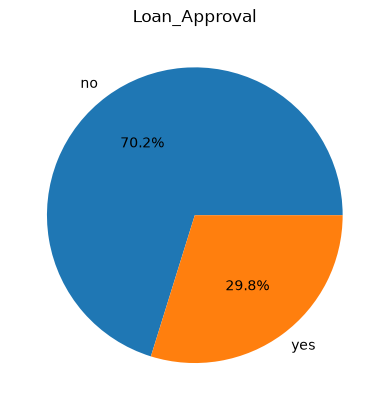

In [4]:
data=df["Loan_Approved"].value_counts()
print(data)
import matplotlib.pyplot as plt
plt.pie(data,labels=["no","yes"],autopct="%1.1f%%")
plt.title("Loan_Approval")

Gender
Male      621
Female    379
Name: count, dtype: int64


<Axes: xlabel='Gender', ylabel='count'>

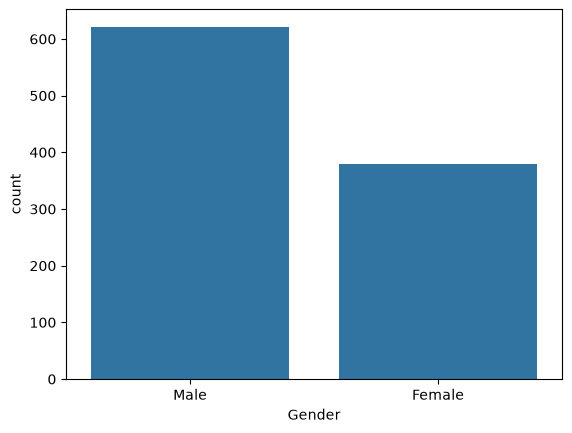

In [5]:
#gender value 
import seaborn as sns
data=df["Gender"].value_counts()
print(data)
sns.barplot(data)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

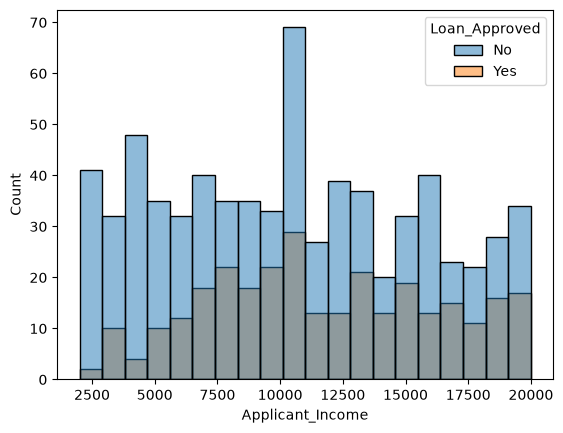

In [6]:
sns.histplot(data=df,x="Applicant_Income",hue="Loan_Approved",bins=20)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

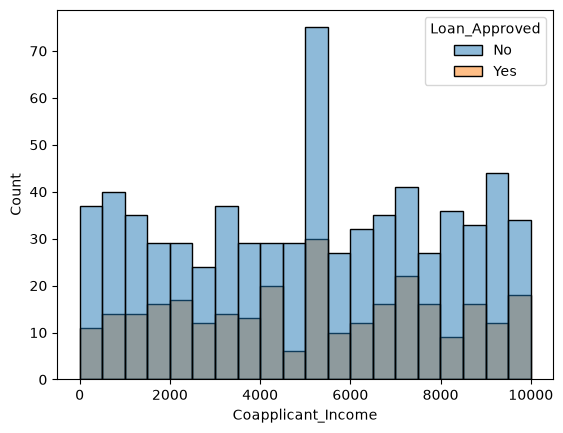

In [7]:
sns.histplot(data=df,x="Coapplicant_Income",hue="Loan_Approved",bins=20)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

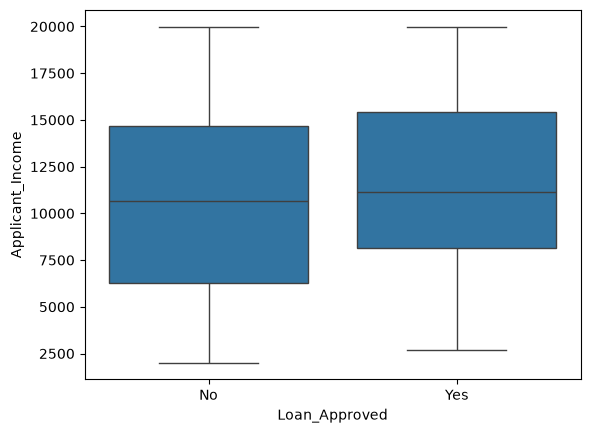

In [8]:
sns.boxplot(data=df,y="Applicant_Income",x="Loan_Approved")

<Axes: xlabel='Loan_Approved', ylabel='Credit_Score'>

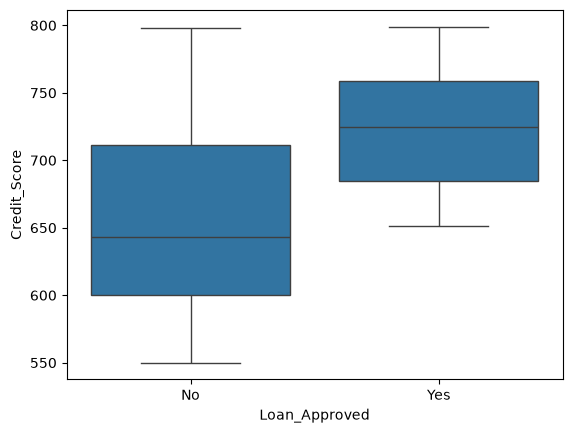

In [9]:
sns.boxplot(data=df,y="Credit_Score",x="Loan_Approved")

In [10]:
#removing applicant id
df=df.drop("Applicant_ID",axis=1)

In [11]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [12]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
df["Marital_Status"]=le.fit_transform(df["Marital_Status"])
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

In [13]:
cols=["Loan_Purpose","Property_Area","Employment_Status","Gender","Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
df1=ohe.fit_transform(df[cols])
df1

array([[0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(1000, 14))

In [21]:
df2=pd.DataFrame(df1,columns=ohe.get_feature_names_out(cols),index=df.index)
df=pd.concat([df.drop(columns=cols),df2],axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Marital_Status                   1000 non-null   int64  
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level                 

In [22]:
num_cols=df.select_dtypes(include=["int64","float64"])
corr_matrics=num_cols.corr()
corr_matrics

,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Property_Area_Semiurban,Property_Area_Urban,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,0.010057,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,...,0.004845,-0.036260,-0.000863,0.005609,0.001419,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.011431,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,...,-0.010058,0.030045,-0.013517,-0.010462,0.023114,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,0.009162,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,...,0.003100,-0.025661,-0.000167,-0.011743,-0.009866,0.048402,-0.066041,0.021232,-0.012960,0.072462
Marital_Status,0.010057,-0.011431,0.009162,1.000000,-0.011410,0.056176,0.018010,-0.014850,-0.004131,0.018450,...,0.056121,-0.065028,-0.041157,0.005550,-0.000948,0.018513,-0.010990,0.015409,-0.019668,0.023773
Dependents,-0.026658,-0.026733,-0.018767,-0.011410,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,...,-0.032278,0.024082,-0.034611,0.079136,0.000396,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,0.056176,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,...,-0.006946,0.004445,-0.016627,-0.035896,-0.008344,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,0.018010,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,...,-0.053971,0.035629,-0.004462,0.042772,-0.012356,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,-0.014850,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,...,0.044898,-0.006156,0.031658,-0.043904,0.022318,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004131,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,...,0.005438,0.016833,0.022435,0.000668,0.006304,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.018450,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,...,0.020061,0.007975,-0.019882,0.000119,-0.041632,0.000897,0.035760,-0.013464,-0.014480,-0.009655


<Axes: >

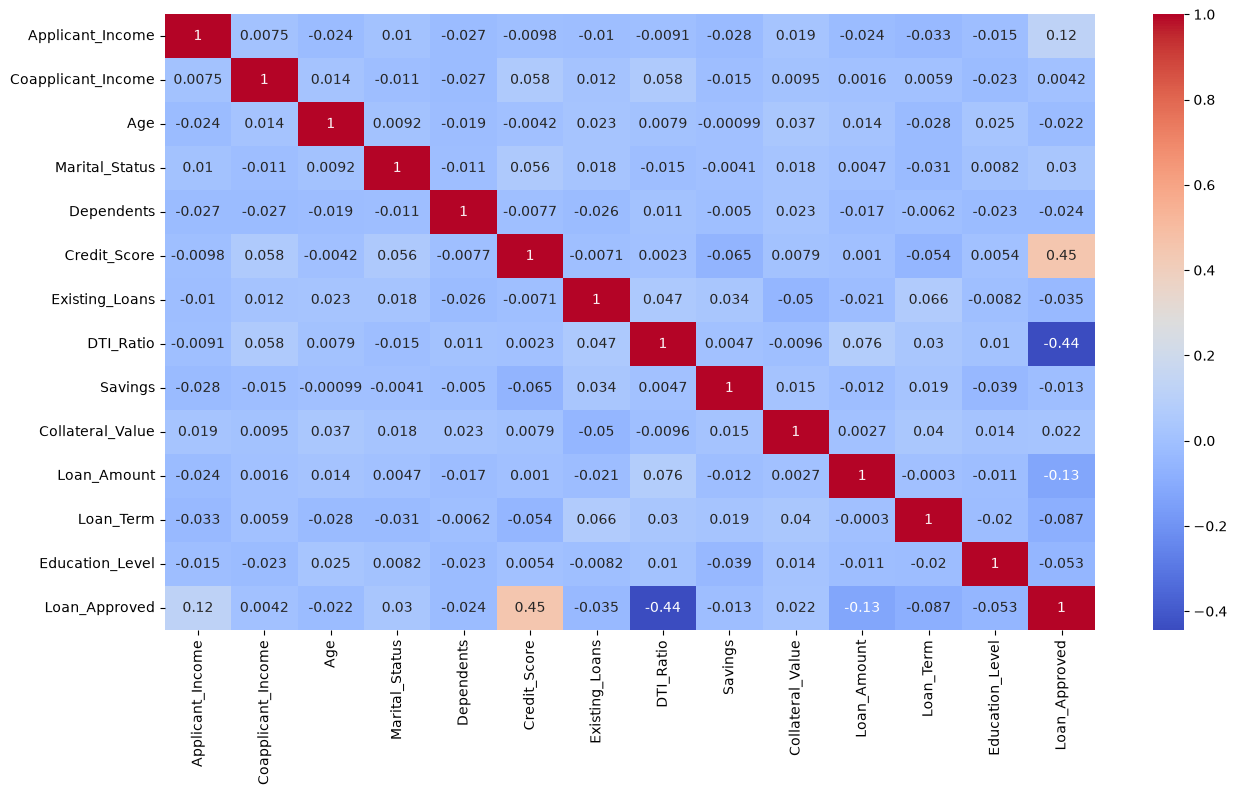

In [16]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrics,
    annot=True,
    cmap="coolwarm"
)

In [23]:
corr_matrics=num_cols.corr()["Loan_Approved"].sort_values(ascending=False)
print(corr_matrics)
df.head()

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status                     0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Property_Area_Semiurban,Property_Area_Urban,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,1,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,1,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [27]:
x=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"].copy()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_trains=scaler.fit_transform(x_train)
x_tests=scaler.transform(x_test)
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [29]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(x_trains,y_train)
y_pred=model.predict(x_tests)
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score;
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1:",f1_score(y_test,y_pred))

Accuracy: 0.865
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1: 0.7692307692307693


In [32]:
#fetured engineering
df["Credit_Score_sq"]=df["Credit_Score"]**2
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df.drop(["Credit_Score","DTI_Ratio"],axis=1)

,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,...,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Credit_Score_sq,DTI_Ratio_sq
0,17795.000000,1387.0,51.0,0,0.0,4.0,19403.000000,45638.0,16619.0,84.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,405769.0,0.2809
1,2860.000000,2679.0,46.0,0,3.0,2.0,2580.000000,49272.0,38687.0,48.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,385641.0,0.0900
2,7390.000000,2106.0,25.0,1,2.0,4.0,13844.000000,6908.0,27943.0,72.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,454276.0,0.0400
3,13964.000000,8173.0,40.0,0,2.0,3.0,9553.000000,10844.0,27819.0,60.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,335241.0,0.0961
4,13284.000000,4223.0,31.0,1,2.0,1.0,9386.000000,37629.0,12741.0,72.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,519841.0,0.0841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0,0.0,0.0,5370.000000,43563.0,8311.0,72.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,310249.0,0.3481
996,3279.000000,6356.0,58.0,0,1.0,3.0,9940.452632,18361.0,22563.0,12.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,417316.0,0.0361
997,15192.000000,8433.0,48.0,1,1.0,1.0,8581.000000,41335.0,16203.0,24.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,443556.0,0.1600
998,9083.000000,7380.0,50.0,1,1.0,3.0,13491.000000,8933.0,10290.0,36.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,559504.0,0.0961


In [33]:
model=GaussianNB()
model.fit(x_trains,y_train)
y_pred=model.predict(x_tests)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1:",f1_score(y_test,y_pred))

Accuracy: 0.865
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1: 0.7692307692307693
